# Task 1 – EDA & Preprocessing: E‑commerce Fraud Data

This notebook:
- Loads and cleans the e‑commerce transaction data
- Merges with IP‑to‑country mapping
- Performs exploratory analysis
- Engineers time‑based and velocity features
- Handles class imbalance with SMOTE (on training set only)
- Saves the processed dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
fraud = pd.read_csv('../data/raw/Fraud_Data.csv', parse_dates=['signup_time', 'purchase_time'])
ip_map = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print('E-commerce shape:', fraud.shape)
fraud.head()

E-commerce shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
# Check missing values
print(fraud.isnull().sum())

# Drop duplicates (if any)
fraud.drop_duplicates(inplace=True)

# Check dtypes
print(fraud.dtypes)

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object


In [7]:
# Robust IP-to-integer conversion
def ip_to_int(ip_val):
    # If it's a string, try standard IP parsing first
    if isinstance(ip_val, str):
        try:
            return int(ipaddress.ip_address(ip_val))
        except ValueError:
            pass
    # Otherwise, try numeric interpretation
    try:
        return int(float(ip_val))
    except (ValueError, TypeError):
        return None

fraud['ip_int'] = fraud['ip_address'].apply(ip_to_int)

# Drop rows where IP conversion failed
before = len(fraud)
fraud.dropna(subset=['ip_int'], inplace=True)
print(f"Rows after dropping unparseable IPs: {len(fraud)} (removed {before - len(fraud)})")

# Ensure both join keys are int64
fraud['ip_int'] = fraud['ip_int'].astype('int64')
ip_map['lower_bound_ip_address'] = ip_map['lower_bound_ip_address'].astype('int64')

# Sort both for merge_asof
fraud.sort_values('ip_int', inplace=True)
ip_map.sort_values('lower_bound_ip_address', inplace=True)

# Range‑based merge
fraud = pd.merge_asof(
    fraud,
    ip_map[['lower_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Clean up temporary columns
fraud.drop(columns=['ip_int', 'lower_bound_ip_address'], inplace=True)

print('Shape after merge:', fraud.shape)
fraud.head(3)

Rows after dropping unparseable IPs: 151112 (removed 0)
Shape after merge: (151112, 12)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.496895,0,NaN
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.138961,0,NaN
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.501505,0,NaN


class
0    136961
1     14151
Name: count, dtype: int64
Fraud percentage: 9.36%


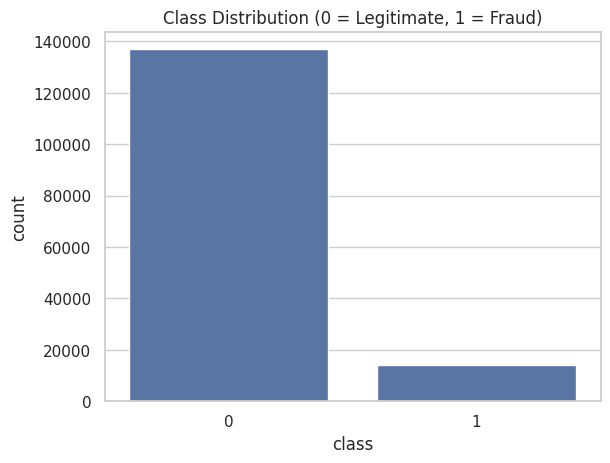

In [8]:
# Target distribution
print(fraud['class'].value_counts())
print(f"Fraud percentage: {fraud['class'].mean()*100:.2f}%")

# Plot
sns.countplot(x='class', data=fraud)
plt.title('Class Distribution (0 = Legitimate, 1 = Fraud)')
plt.show()

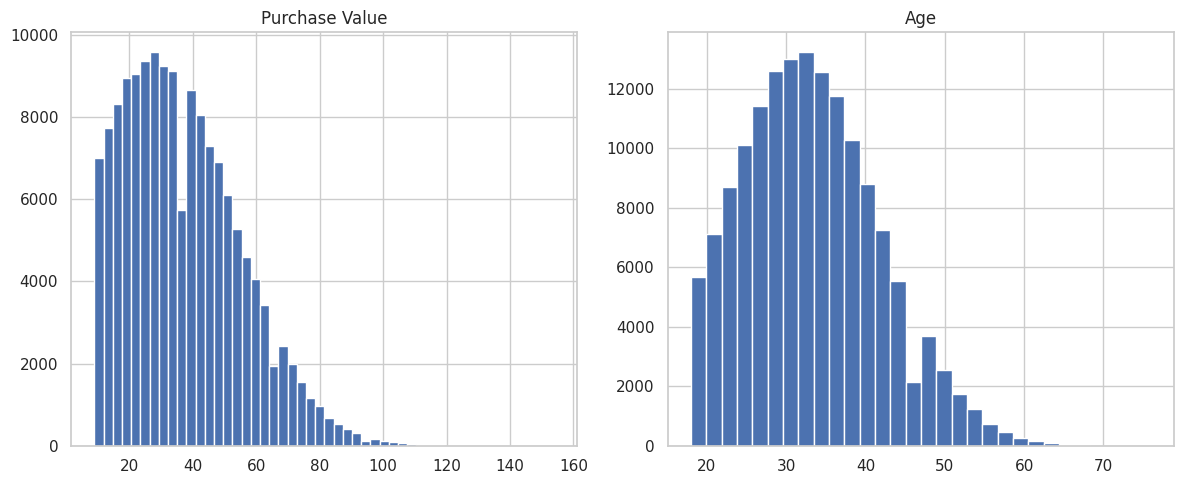

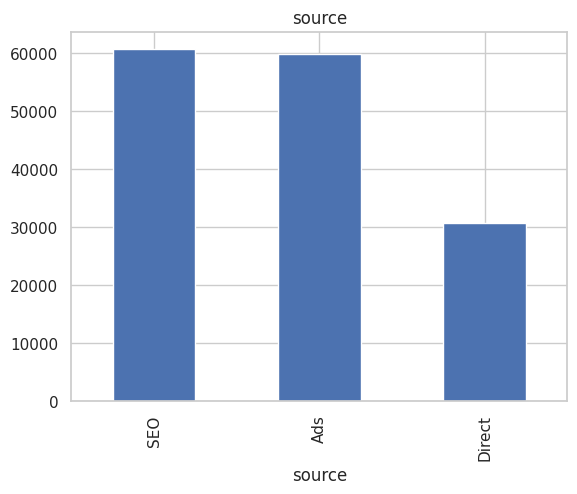

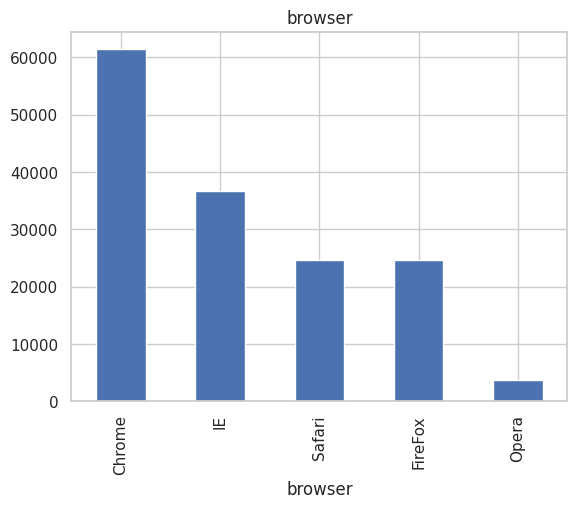

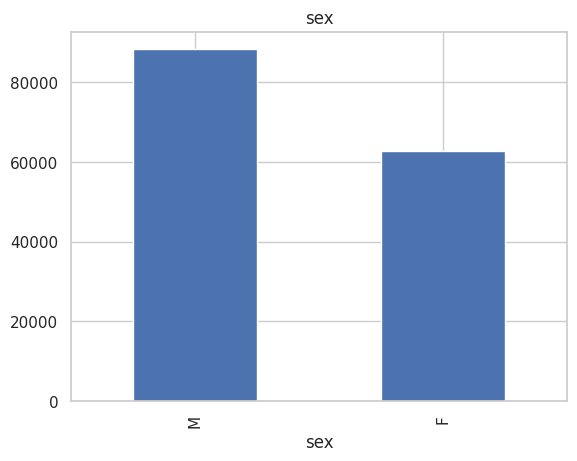

In [9]:
# purchase_value distribution
fig, ax = plt.subplots(1,2, figsize=(12,5))
fraud['purchase_value'].hist(bins=50, ax=ax[0])
ax[0].set_title('Purchase Value')
fraud['age'].hist(bins=30, ax=ax[1])
ax[1].set_title('Age')
plt.tight_layout()
plt.show()

# Categorical features
for col in ['source', 'browser', 'sex']:
    fraud[col].value_counts().plot(kind='bar', title=col)
    plt.show()

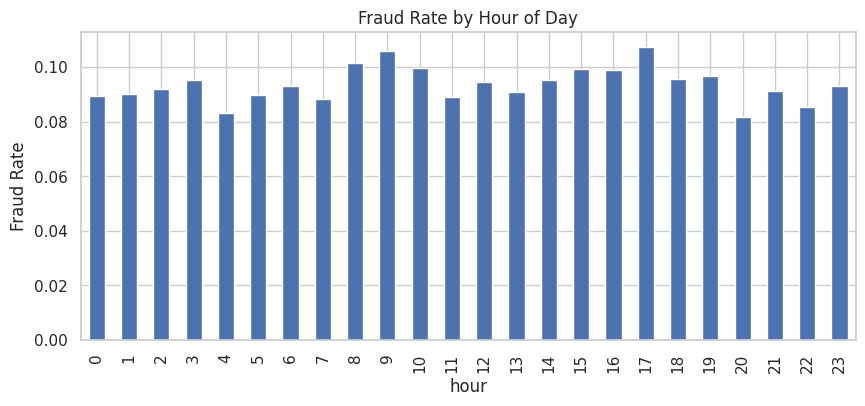

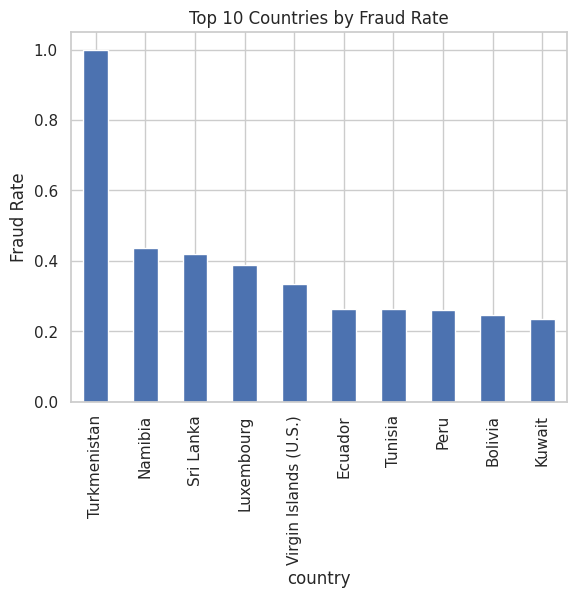

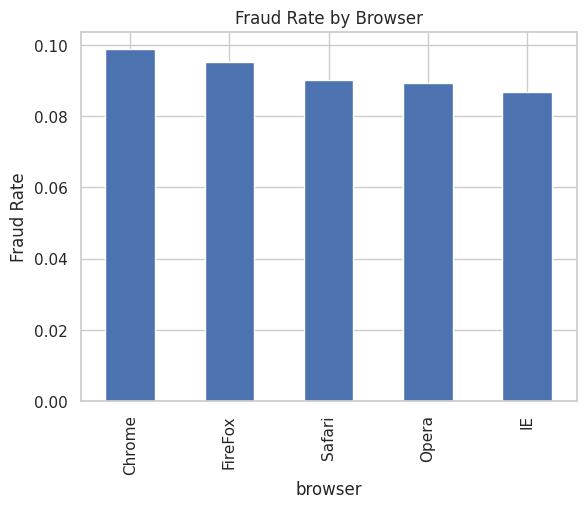

In [10]:
# Fraud by hour of day
fraud['hour'] = fraud['purchase_time'].dt.hour
fraud.groupby('hour')['class'].mean().plot(kind='bar', figsize=(10,4))
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.show()

# Fraud by country
fraud.groupby('country')['class'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Countries by Fraud Rate')
plt.ylabel('Fraud Rate')
plt.show()

# Fraud by browser
fraud.groupby('browser')['class'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Fraud Rate by Browser')
plt.ylabel('Fraud Rate')
plt.show()

In [ ]:
# Time features
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek   # Monday=0

# Time since signup (hours)
fraud['time_since_signup'] = (fraud['purchase_time'] - fraud['signup_time']).dt.total_seconds() / 3600

# Transaction count per user
fraud['user_txn_count'] = fraud.groupby('user_id')['user_id'].transform('count')

# Transaction velocity: count of transactions by same user in last 24h (excluding the current one)
def rolling_24h_count(user_df):
    """For a single user, compute rolling count in the last 24 hours."""
    # Sort by time and set purchase_time as the index (required for time‑based rolling)
    user_df = user_df.sort_values('purchase_time').set_index('purchase_time')
    # Create a dummy series of 1s to count
    user_df['ones'] = 1
    # Rolling count: '24h' window, closed='left' excludes the current row
    user_df['txn_count'] = user_df['ones'].rolling('24h', closed='left').count()
    return user_df['txn_count']

# Apply per user – group_keys=False keeps the original row indices
fraud = fraud.sort_values(['user_id', 'purchase_time'])
fraud['txn_last_24h'] = fraud.groupby('user_id', group_keys=False).apply(rolling_24h_count)

# Fill NaN (the first transaction of each user) with 0
fraud['txn_last_24h'] = fraud['txn_last_24h'].fillna(0).astype(int)

# Quick check
print(fraud[['user_id', 'purchase_time', 'txn_last_24h']].head(10))

In [13]:
# Drop IDs and raw timestamps
drop_cols = ['user_id', 'signup_time', 'purchase_time', 'ip_address', 'device_id']
X = fraud.drop(columns=['class'] + drop_cols)
y = fraud['class']

# Separate categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()
print('Categorical:', cat_cols)
print('Numerical:', num_cols)

Categorical: ['source', 'browser', 'sex', 'country']
Numerical: ['purchase_value', 'age', 'hour', 'hour_of_day', 'day_of_week', 'time_since_signup', 'user_txn_count']


In [14]:
# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# SMOTE on training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 109568, 1: 11321}
After SMOTE: {0: 109568, 1: 109568}


In [15]:
# Save the resampled training set and the original test set
import pickle
import os
os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/fraud_train.pkl', 'wb') as f:
    pickle.dump((X_train_res, y_train_res), f)
with open('../data/processed/fraud_test.pkl', 'wb') as f:
    pickle.dump((X_test_scaled, y_test, preprocessor), f)

print('Processed data saved.')

Processed data saved.
